In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score)
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import average_precision_score
from sklearn.metrics import precision_recall_curve
from warnings import filterwarnings
filterwarnings("ignore")    

In [75]:
df = pd.read_csv('../datos/procesados/dataset_variables_discriminativas.csv')
df.head()

,DISPOSITIVO_NUEVO,NUM_INTENTOS_FALLIDOS,BENEFICIARIO_NUEVO,CAMBIO_CLAVE_RECIENTE,CANAL,MONTO_TRANSACCION,OPERACION_NOCTURNA,DISTANCIA_UBICACION_KM,PAIS_DESTINO,TIPO_TRANSACCION,FRAUDE
0,0,0,0,0,App,186052,1,81.92,CO,Pago proveedor,0
1,0,2,0,0,App,1200273,1,5.35,CO,Desembolso,0
2,0,0,0,0,Cajero,242589,0,9.13,CO,Pago factura,0
3,1,0,0,0,Cajero,2490968,0,7.69,CO,Transferencia,0
4,0,0,0,0,Cajero,334308,0,33.22,CO,Transferencia,0


In [76]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   DISPOSITIVO_NUEVO       60000 non-null  int64  
 1   NUM_INTENTOS_FALLIDOS   60000 non-null  int64  
 2   BENEFICIARIO_NUEVO      60000 non-null  int64  
 3   CAMBIO_CLAVE_RECIENTE   60000 non-null  int64  
 4   CANAL                   60000 non-null  str    
 5   MONTO_TRANSACCION       60000 non-null  int64  
 6   OPERACION_NOCTURNA      60000 non-null  int64  
 7   DISTANCIA_UBICACION_KM  60000 non-null  float64
 8   PAIS_DESTINO            60000 non-null  str    
 9   TIPO_TRANSACCION        60000 non-null  str    
 10  FRAUDE                  60000 non-null  int64  
dtypes: float64(1), int64(7), str(3)
memory usage: 5.0 MB


In [77]:
X = df.drop(columns='FRAUDE')
y = df['FRAUDE']

In [78]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape


((48000, 10), (12000, 10), (48000,), (12000,))

Comprobemos el desbalance de cargas

In [79]:
print("Fraude en entrenamiento:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nFraude en prueba:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Fraude en entrenamiento:
FRAUDE
0    95.7
1     4.3
Name: proportion, dtype: float64

Fraude en prueba:
FRAUDE
0    95.81
1     4.19
Name: proportion, dtype: float64


In [80]:
variables_numericas = ['DISPOSITIVO_NUEVO', 'NUM_INTENTOS_FALLIDOS', 'BENEFICIARIO_NUEVO',
    'CAMBIO_CLAVE_RECIENTE', 'MONTO_TRANSACCION', 'OPERACION_NOCTURNA', 'DISTANCIA_UBICACION_KM']

variables_categoricas = ['CANAL', 'PAIS_DESTINO', 'TIPO_TRANSACCION']

In [ ]:
preprocesamiento = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), variables_categoricas),
        ('num', 'passthrough', variables_numericas)])

**Primer modelo: DecisionTreeClassifier**

In [ ]:
modelo_tree = DecisionTreeClassifier(
    max_depth=5,
    class_weight= 'balanced',
    random_state=42
)

pipeline_tree = Pipeline([
    ('preprocesamiento', preprocesamiento),
    ('modelo', modelo_tree)
])

In [83]:
pipeline_tree.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['DISPOSITIVO_NUEVO','NUM_INTENTOS_FALLIDOS','BENEFICIARIO_NUEVO',..., 'DISTANCIA_UBICACION_KM','PAIS_DESTINO','TIPO_TRANSACCION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

**Predicciones**

In [84]:
y_pred_tree = pipeline_tree.predict(x_test)
y_prob_tree = pipeline_tree.predict_proba(x_test)[:, 1]

**Evaluacion del modelo**

In [85]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_tree))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_tree))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_tree))

Matriz de confusión:
[[8610 2887]
 [ 269  234]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.75      0.85     11497
           1       0.07      0.47      0.13       503

    accuracy                           0.74     12000
   macro avg       0.52      0.61      0.49     12000
weighted avg       0.93      0.74      0.82     12000


ROC-AUC:
0.6532803699677209


**Insight importantes de este modelo**

El modelo logra identificar aproximadamente el 47% de las operaciones fraudulentas, pero presenta una baja precisión del 7%.

En un banco esto podría ser problemático porque generaríamos demasiadas alertas que posteriormente deberían ser revisadas.

**Segundo modelo XGBoost**

In [ ]:
modelo_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric= 'logloss'
)

In [87]:
pipeline_XGB = Pipeline([
    ('preprocesamiento', preprocesamiento),
    ('modelo', modelo_xgb)
])


In [88]:
pipeline_XGB.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['DISPOSITIVO_NUEVO','NUM_INTENTOS_FALLIDOS','BENEFICIARIO_NUEVO',..., 'DISTANCIA_UBICACION_KM','PAIS_DESTINO','TIPO_TRANSACCION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

In [89]:
y_pred_XGB = pipeline_XGB.predict(x_test)
y_prob_XGB = pipeline_XGB.predict_proba(x_test)[:, 1]

**Evaluación del modelo**

In [119]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_XGB))

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred_XGB))

print("\nROC-AUC:")
print(roc_auc_score(y_test, y_prob_XGB))

Matriz de confusión:
[[11497     0]
 [  503     0]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98     11497
           1       0.00      0.00      0.00       503

    accuracy                           0.96     12000
   macro avg       0.48      0.50      0.49     12000
weighted avg       0.92      0.96      0.94     12000


ROC-AUC:
0.6778424866993568


**Definamos umbrales para XGB**

In [91]:
umbrales = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]

resultados_umbral = []

for umbral in umbrales:

    y_pred_umbral = (y_prob_XGB >= umbral).astype(int)

    precision = precision_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    resultados_umbral.append({
        'Umbral': umbral,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Alertas': y_pred_umbral.sum()
    })

df_umbral = pd.DataFrame(resultados_umbral)

df_umbral

,Umbral,Precision,Recall,F1,Alertas
0,0.50,0.000000,0.000000,0.000000,0
1,0.40,0.000000,0.000000,0.000000,5
2,0.30,0.095238,0.003976,0.007634,21
3,0.20,0.192661,0.041750,0.068627,109
4,0.15,0.159836,0.077535,0.104418,244
5,0.10,0.130194,0.186879,0.153469,722
6,0.05,0.080445,0.489066,0.138163,3058


El mejor F1 observado corresponde al umbral 0.10 (15.35%), mientras que el umbral 0.05 permite alcanzar un Recall cercano al 49%, a costa de generar 3.058 alertas y una Precision de apenas 8.04%. Esto indica que la selección del umbral debe definirse de acuerdo con la capacidad operativa del proceso de investigación y el costo relativo de los falsos positivos y falsos negativos.

**Generamos los mismos umbrales para Decision tree**

In [92]:
umbrales = [0.50, 0.40, 0.30, 0.20, 0.15, 0.10, 0.05]

resultados_tree = []

for umbral in umbrales:

    y_pred_umbral = (y_prob_tree >= umbral).astype(int)

    precision = precision_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred_umbral,
        zero_division=0
    )

    resultados_tree.append({
        'Umbral': umbral,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Alertas': y_pred_umbral.sum()
    })

df_umbral_tree = pd.DataFrame(resultados_tree)

df_umbral_tree

,Umbral,Precision,Recall,F1,Alertas
0,0.50,0.074976,0.465209,0.129139,3121
1,0.40,0.058656,0.737575,0.108670,6325
2,0.30,0.041813,0.996024,0.080256,11982
3,0.20,0.041813,0.996024,0.080256,11982
4,0.15,0.041813,0.996024,0.080256,11982
5,0.10,0.041813,0.996024,0.080256,11982
6,0.05,0.041813,0.996024,0.080256,11982


El modelo presenta una alta sensibilidad para identificar operaciones fraudulentas, pero con una baja precisión, generando un volumen significativo de falsas alertas. El descenso del umbral incrementa rápidamente el Recall, alcanzando aproximadamente 99.6%, pero genera 11.982 alertas y reduce la Precision a 4.18%. Esto evidencia que el modelo, en su estado actual, no logra discriminar adecuadamente entre transacciones fraudulentas y legítimas.

**Configuracion para nuevo modelo XGB Balanceado**

In [93]:
scale_pos = y_train.value_counts()[0] / y_train.value_counts()[1]

print("scale_pos_weight:", scale_pos)

scale_pos_weight: 22.25581395348837


In [94]:
modelo_xgb_bal = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss'
)

In [95]:
pipeline_xgb_bal = Pipeline([
    ('preprocesamiento', preprocesamiento),
    ('modelo', modelo_xgb_bal)
])

In [96]:
pipeline_xgb_bal.fit(x_train, y_train)  

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocesamiento', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['DISPOSITIVO_NUEVO','NUM_INTENTOS_FALLIDOS','BENEFICIARIO_NUEVO',..., 'DISTANCIA_UBICACION_KM','PAIS_DESTINO','TIPO_TRANSACCION']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (defaul

In [97]:
y_pred_xgb_bal = pipeline_xgb_bal.predict(x_test)
y_prob_xgb_bal = pipeline_xgb_bal.predict_proba(x_test)[:, 1]

In [98]:
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred_xgb_bal))

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        y_pred_xgb_bal,
        zero_division=0
    )
)

print("\nROC-AUC:")
print(
    roc_auc_score(
        y_test,
        y_prob_xgb_bal
    )
)

Matriz de confusión:
[[8576 2921]
 [ 269  234]]

Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.97      0.75      0.84     11497
           1       0.07      0.47      0.13       503

    accuracy                           0.73     12000
   macro avg       0.52      0.61      0.49     12000
weighted avg       0.93      0.73      0.81     12000


ROC-AUC:
0.6654515803327379


El modelo presenta una capacidad de discriminación limitada (ROC-AUC = 0.665) y un desempeño especialmente bajo en la identificación de fraude.  Aalcanza un Recall de 46.5%, detectando aproximadamente la mitad de las operaciones fraudulentas, presenta una Precision de apenas 7.5%, generando un elevado número de falsas alarmas.

La matriz de confusión evidencia 234 fraudes correctamente detectados frente a 269 fraudes no identificados y 2.921 operaciones legítimas clasificadas incorrectamente como fraude. Por tanto, aunque el modelo puede servir como mecanismo inicial de generación de alertas, su desempeño no sería suficiente para considerarlo un sistema robusto de detección de fraude en producción.

**Average Precisión** 

In [114]:
ap_tree = average_precision_score(
    y_test,
    y_prob_tree
)

ap_xgb = average_precision_score(
    y_test,
    y_prob_xgb_bal
)

print("Average Precision - Decision Tree:", ap_tree)
print("Average Precision - XGBoost balanceado:", ap_xgb)

Average Precision - Decision Tree: 0.07664994087069792
Average Precision - XGBoost balanceado: 0.08843597565832027


Esta métrica resume qué tan bien un modelo mantiene una buena Precision mientras aumenta el Recall. Vemos que XGBoost presenta una capacidad ligeramente superior para identificar y priorizar transacciones fraudulentas frente al árbol de decisión, aunque ambos modelos presentan un desempeño limitado.

**Curva de Precision vs Recall**

In [117]:
precision_tree, recall_tree, thresholds_tree = precision_recall_curve(
    y_test,
    y_prob_tree
)

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(
    y_test,
    y_prob_xgb_bal
)

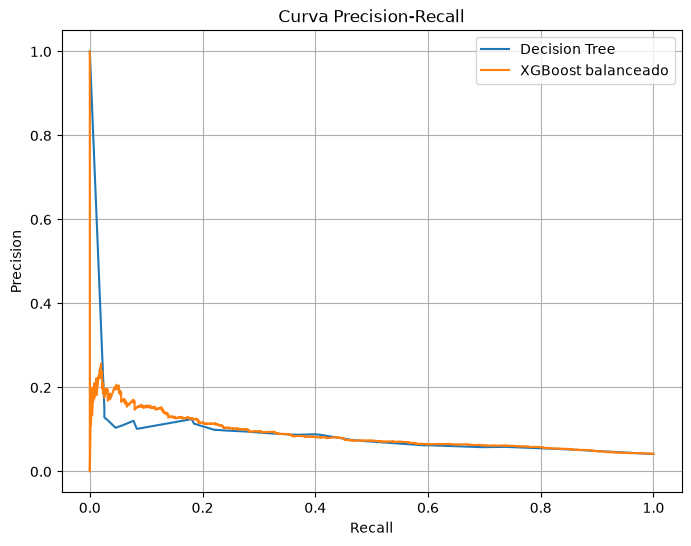

In [118]:
plt.figure(figsize=(8, 6))

plt.plot(
    recall_tree,
    precision_tree,
    label='Decision Tree'
)

plt.plot(
    recall_xgb,
    precision_xgb,
    label='XGBoost balanceado'
)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Curva Precision-Recall')
plt.legend()
plt.grid(True)

plt.show()

El XGBoost se comporta un poco mejor que el árbol, pero los dos tienen el mismo problema: cuando queremos detectar más fraudes, aumentan mucho las falsas alarmas. Esto nos muestra que el modelo todavía tiene capacidad predictiva limitada.

**Generamos los umbrales para xgb_bal**

In [103]:
umbrales_xgb_bal = [
    0.50, 0.40, 0.30, 0.20,
    0.15, 0.10, 0.08, 0.06,
    0.05, 0.04, 0.03, 0.02
]

resultados_xgb_bal = []

for umbral in umbrales_xgb_bal:

    y_pred = (y_prob_xgb_bal >= umbral).astype(int)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    resultados_xgb_bal.append({
        'Umbral': umbral,
        'Precision': precision,
        'Recall': recall,
        'F1': f1,
        'Alertas': y_pred.sum()
    })

df_xgb_bal_umbral = pd.DataFrame(resultados_xgb_bal)

df_xgb_bal_umbral

,Umbral,Precision,Recall,F1,Alertas
0,0.50,0.074168,0.465209,0.127939,3155
1,0.40,0.061500,0.725646,0.113389,5935
2,0.30,0.048575,0.894632,0.092147,9264
3,0.20,0.042824,0.990060,0.082097,11629
4,0.15,0.042064,1.000000,0.080732,11958
5,0.10,0.041934,1.000000,0.080493,11995
6,0.08,0.041934,1.000000,0.080493,11995
7,0.06,0.041924,1.000000,0.080474,11998
8,0.05,0.041920,1.000000,0.080467,11999
9,0.04,0.041917,1.000000,0.080461,12000


El análisis de umbrales evidencia un fuerte compromiso entre Recall y Precision. Aunque es posible alcanzar un Recall cercano al 100% reduciendo el umbral, esto genera un volumen de alertas excesivamente elevado y una Precision inferior al 5%. El umbral de 0,50 presenta el mejor F1 entre los valores evaluados, aunque su Precision de 7,42% continúa siendo baja. Esto confirma que el modelo tiene una capacidad predictiva limitada y que su utilización en producción requeriría datos más robustos y una definición del umbral basada en los costos reales de falsos positivos y falsos negativos.

**Interpretación del modelo – Feature Importance**

In [129]:
modelo_final = pipeline_xgb_bal.named_steps['modelo']

importancias = modelo_final.feature_importances_

print(len(importancias))

23


In [130]:
preprocesador_final = pipeline_xgb_bal.named_steps['preprocesamiento']

nombres_variables = preprocesador_final.get_feature_names_out()

print(len(nombres_variables))

23


In [128]:
df_importancia = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
})

df_importancia = df_importancia.sort_values(
    by='Importancia',
    ascending=False
)

df_importancia.head(4)

,Variable,Importancia
16,num__DISPOSITIVO_NUEVO,0.178716
18,num__BENEFICIARIO_NUEVO,0.105926
17,num__NUM_INTENTOS_FALLIDOS,0.060822
19,num__CAMBIO_CLAVE_RECIENTE,0.058974


DISPOSITIVO_NUEVO es la característica más importante del modelo, con una importancia de 0.1787 (17.87%).